# 105. Visual attention 을 이용한 Image captioning

- Google Tutorial https://www.tensorflow.org/tutorials/text/image_captioning?hl=ko 참조  

- MSCOCO dataset 대신 Flicker8k dataset 으로 변경

아래 사진에서 "a surfer riding on a wave" 가 caption 되도록 attention-based model 작성

<img src="https://tensorflow.org/images/surf.jpg" width="400" />

- attention based model 은 image 의 어떤 부분을 caption 생성 도중 주목할 것인지 가능하도록 해 준다.

<img src="https://tensorflow.org/images/imcap_prediction.png" width="600" />

### Google Tutorial 의 MSCOCO dataset size (330K images) 가 매우 크므로 Flicker8 으로 dataset 을 변경
- Google drive 에 사전 upload

In [25]:
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    root_captioning = "/content/drive/My Drive/Flicker8"
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    root_captioning = r'./Flicker8'
    
import tensorflow as tf
tf.__version__

Note: not using Google CoLab


'2.0.0'

In [26]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import string
import numpy as np
import os
import time
import pickle
from tqdm import tqdm

## Download and prepare the Flicker8k dataset

### Text cleansing
- str.maketrans(x, y, z)
    - x, y - 동일 길이의 mapping string
    - z - 결과에 None 을 반환할 characters string
    - 반환값 - str.translate() 에서 사용할 translation table (ascii value)
- str.translate(traslation_table)

In [27]:
print(string.punctuation)
null_table = str.maketrans('', '', string.punctuation)
print(null_table)
print("abc!def#".translate(null_table))

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
{33: None, 34: None, 35: None, 36: None, 37: None, 38: None, 39: None, 40: None, 41: None, 42: None, 43: None, 44: None, 45: None, 46: None, 47: None, 58: None, 59: None, 60: None, 61: None, 62: None, 63: None, 64: None, 91: None, 92: None, 93: None, 94: None, 95: None, 96: None, 123: None, 124: None, 125: None, 126: None}
abcdef


- 처음 6 line 출력


In [28]:
filename = root_captioning + "/Flickr8k_text/Flickr8k.token.txt"
fp = open(filename, 'r')

for i, line in enumerate(fp.read().split('\n')):
    if i > 5:
        break
    tokens = line.split()
    print(tokens)

['1000268201_693b08cb0e.jpg#0', 'A', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a', 'set', 'of', 'stairs', 'in', 'an', 'entry', 'way', '.']
['1000268201_693b08cb0e.jpg#1', 'A', 'girl', 'going', 'into', 'a', 'wooden', 'building', '.']
['1000268201_693b08cb0e.jpg#2', 'A', 'little', 'girl', 'climbing', 'into', 'a', 'wooden', 'playhouse', '.']
['1000268201_693b08cb0e.jpg#3', 'A', 'little', 'girl', 'climbing', 'the', 'stairs', 'to', 'her', 'playhouse', '.']
['1000268201_693b08cb0e.jpg#4', 'A', 'little', 'girl', 'in', 'a', 'pink', 'dress', 'going', 'into', 'a', 'wooden', 'cabin', '.']
['1001773457_577c3a7d70.jpg#0', 'A', 'black', 'dog', 'and', 'a', 'spotted', 'dog', 'are', 'fighting']


In [29]:
lookup = dict()
max_length = 0

fp = open(filename, 'r')

for i, line in enumerate(fp.read().split('\n')):
    if len(line) >= 2:
        tokens = line.split()
        id = tokens[0].split('.')[0]       #1000268201_693b08cb0e - image ID    
        desc = tokens[1:]       #['A', 'girl', 'going', 'into', 'a', 'wooden', 'building', '.']
       # Cleanup description
        desc = [w.lower() for w in desc]
        desc = [w.translate(null_table) for w in desc] # 구둣점 제거
        desc = [w for w in desc if len(w)>1]           # a 같은 한글자 단어 제외
        desc = [w for w in desc if w.isalpha()]        # 알파벳 문자외는 제외

        max_length = max(max_length, len(desc))        # 가장 긴 description 길이 (단어수)

        if id not in lookup:
            lookup[id] = list()

        lookup[id].append(' '.join(desc))   # cleansing 된 description 생성

In [30]:
print(len(lookup))
print(list(lookup.items())[0])

8092
('1000268201_693b08cb0e', ['child in pink dress is climbing up set of stairs in an entry way', 'girl going into wooden building', 'little girl climbing into wooden playhouse', 'little girl climbing the stairs to her playhouse', 'little girl in pink dress going into wooden cabin'])


In [31]:
annotations = list()

for id, captions in lookup.items():
    for caption in captions:
        annot = dict()
        annot['caption'] = caption
        annot['image_id'] = id
        annotations.append(annot)

annotations[:3]

[{'caption': 'child in pink dress is climbing up set of stairs in an entry way',
  'image_id': '1000268201_693b08cb0e'},
 {'caption': 'girl going into wooden building',
  'image_id': '1000268201_693b08cb0e'},
 {'caption': 'little girl climbing into wooden playhouse',
  'image_id': '1000268201_693b08cb0e'}]

### image file 갯수 확인
- 이전 작업시 생성된 .npy file 제외
- colab 시간 초과시 재수행 (수행 안되어도 이후 작업에 지장 없음)

In [32]:
img_directory = root_captioning +  '/Flickr8k_Dataset/Flicker8k_Dataset/'
imgs = [img for img in os.listdir(img_directory) if img.split('.')[-1] != 'npy']  
npys = [img for img in os.listdir(img_directory) if img.split('.')[-1] == 'npy']  
print(len(imgs))
print(len(npys))
print(imgs[:5])
print(npys[:5])

8091
8091
['1000268201_693b08cb0e.jpg', '1001773457_577c3a7d70.jpg', '1002674143_1b742ab4b8.jpg', '1003163366_44323f5815.jpg', '1007129816_e794419615.jpg']
['1000268201_693b08cb0e.jpg.npy', '1001773457_577c3a7d70.jpg.npy', '1002674143_1b742ab4b8.jpg.npy', '1003163366_44323f5815.jpg.npy', '1007129816_e794419615.jpg.npy']


### 모든 caption 과 image path 를 하나의 list 에 저장
- caption 에 `<start>`, `<end>` token 추가

In [33]:
all_captions = []
all_img_paths = []

for annot in annotations:
    caption = '<start> ' + annot['caption'] + ' <end>'
    image_id = annot['image_id']

    full_coco_image_path = img_directory +  image_id + '.jpg'

    if os.path.exists(full_coco_image_path):
        all_img_paths.append(full_coco_image_path)
        all_captions.append(caption)
    else:
        print("No image file found :", full_coco_image_path)

No image file found : ./Flicker8/Flickr8k_Dataset/Flicker8k_Dataset/2258277193_586949ec62.jpg
No image file found : ./Flicker8/Flickr8k_Dataset/Flicker8k_Dataset/2258277193_586949ec62.jpg
No image file found : ./Flicker8/Flickr8k_Dataset/Flicker8k_Dataset/2258277193_586949ec62.jpg
No image file found : ./Flicker8/Flickr8k_Dataset/Flicker8k_Dataset/2258277193_586949ec62.jpg
No image file found : ./Flicker8/Flickr8k_Dataset/Flicker8k_Dataset/2258277193_586949ec62.jpg


In [34]:
print(all_captions[:5])
print(all_img_paths[:5])

['<start> child in pink dress is climbing up set of stairs in an entry way <end>', '<start> girl going into wooden building <end>', '<start> little girl climbing into wooden playhouse <end>', '<start> little girl climbing the stairs to her playhouse <end>', '<start> little girl in pink dress going into wooden cabin <end>']
['./Flicker8/Flickr8k_Dataset/Flicker8k_Dataset/1000268201_693b08cb0e.jpg', './Flicker8/Flickr8k_Dataset/Flicker8k_Dataset/1000268201_693b08cb0e.jpg', './Flicker8/Flickr8k_Dataset/Flicker8k_Dataset/1000268201_693b08cb0e.jpg', './Flicker8/Flickr8k_Dataset/Flicker8k_Dataset/1000268201_693b08cb0e.jpg', './Flicker8/Flickr8k_Dataset/Flicker8k_Dataset/1000268201_693b08cb0e.jpg']


### data shuffle

In [35]:
all_captions, all_img_paths = shuffle(all_captions, all_img_paths, random_state=1)
len(all_captions), len(all_img_paths )

(40455, 40455)

### train 시간 단축을 위해 일부 data 만 선택

- NUM_EXAMPLES = 6000, 12000, 20000, 40000 으로 accuracy 비교

In [36]:
NUM_EXAMPLES = 6000  # google colab 

train_captions = all_captions[:NUM_EXAMPLES]
train_img_paths = all_img_paths[:NUM_EXAMPLES]

In [37]:
print(len(train_captions), len(train_img_paths))
print(len(set(train_img_paths)))  # 중복 제거한 train image 수

6000 6000
4488


### 모든 경로의 file 이 실제 존재하는지 sanity check

In [38]:
# sanity check
exist_cnt = 0
not_exist_cnt = 0

for path in train_img_paths:
    if os.path.exists(path):
        exist_cnt += 1
    else:
        not_exist_cnt += 1
        print(path)

print(exist_cnt, not_exist_cnt)

6000 0


## InceptionV3 를 이용한 image preprocess
- pre-trained InceptionV3 를 이용하여 각 image 를 분류  
- 마지막 convolutional layer 에서 출력되는 feature 를 context vector 로 이용
- image 를 InceptionV3 input size 로 resize :  299px by 299px

* [preprocess_input](https://www.tensorflow.org/api_docs/python/tf/keras/applications/inception_v3/preprocess_input) method 를 이용하여 image normalize (-1 to 1 사이로 pixel 값 조정)

In [39]:
def load_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (299, 299))
    img = tf.keras.applications.inception_v3.preprocess_input(img)
    return img, image_path

## pretrained Imagenet weights 로 InceptionV3 초기화

- 마지막 convolutional layer 의 shape 은 ```8x8x2048``` 이고 이 resulting vector 를 이용하여 attention 작성

- model training 의 효율화를 위해 각 image 의 resulting vector 를 저장할 dictoinary(image_name --> feature_vector) 생성  

- dictionary 를 pickle file 로 disk 에 저장

In [40]:
image_model = tf.keras.applications.inception_v3.InceptionV3(weights='imagenet')
new_input = image_model.input
hidden_layer = image_model.layers[-3].output

image_features_extract_model = tf.keras.Model(new_input, hidden_layer)

In [41]:
image_features_extract_model.layers[-1].output

<tf.Tensor 'mixed10/Identity:0' shape=(None, 8, 8, 2048) dtype=float32>

## InceptionV3 에서 출력된 feature 를 cache 에 저장
- Image 를 feature extraction 하는 것은 computationally expensive 하므로 사전에 caching 하여 중복 작업 방지
- InceptionV3 로 image pre-processing 및 output 을 disk 에 caching  (image 당 8 \* 8 \* 2048 floats)

- caching 은 Colab GPU 작업 시 6000 건 약 30 분 


In [42]:
save_folder = img_directory
if not os.path.exists(save_folder):
  os.mkdir(save_folder)
print(save_folder)

./Flicker8/Flickr8k_Dataset/Flicker8k_Dataset/


In [ ]:
s = time.time()
save_cnt = 0

BATCH_SIZE = 16

# Get unique images
encode_train = sorted(set(train_img_paths))

image_dataset = tf.data.Dataset.from_tensor_slices(encode_train)
image_dataset = image_dataset.map(load_image).batch(BATCH_SIZE)

for img, path in tqdm(image_dataset):
    batch_features = image_features_extract_model(img)
    batch_features = tf.reshape(batch_features,   # [BATCH_SIZE, 8*8, 2048]
                    (batch_features.shape[0], -1, batch_features.shape[3])) 
                        
    for bf, p in zip(batch_features, path):
        path_of_feature = p.numpy().decode("utf-8")
        file_path = path_of_feature.split('Flicker8k_Dataset/')
        path_of_feature = save_folder + file_path[1]
        if not os.path.exists(path_of_feature + '.npy'):
            np.save(path_of_feature, bf.numpy())
            save_cnt += 1
        
print(f"image 의 feature vector 변환 시간 : {save_cnt} 건, {time.time() - s}")

- last batch_featues, path 의 data 내용 확인

In [ ]:
print(batch_features.shape)
print(path[0])
print(bf.shape)
path_of_feature

## Caption 을 preprocess 및 tokenize

- caption tokenize  

- vocaburary size 를 5000 으로 제한. 다른 단어들은 "UNK" 로 치환  

- word-to-index 와 index-to-word mapping 생성  

- 가장 긴 sequence 를 기준으로 zero padding

In [43]:
# Choose the top 5000 words from the vocabulary
top_k = 5000
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=top_k, oov_token="<unk>", filters='')
tokenizer.fit_on_texts(train_captions)
train_sequences = tokenizer.texts_to_sequences(train_captions)

In [44]:
tokenizer.word_index['<pad>'] = 0
tokenizer.index_word[0] = '<pad>'

In [45]:
# 각 vector 들을 caption 의 max_length 로 padding
train_sequences = tf.keras.preprocessing.sequence.pad_sequences(train_sequences, padding='post')

In [46]:
# attention weight 를 저장하는데 사용할 max_length 계산
max_length = max([len(seq) for seq in train_sequences])
max_length

29

## Data 를 train 과 test set 으로 분리

In [47]:
# 80-20 비율로 train, validaton set 분할
img_name_train, img_name_val, cap_train, cap_val \
             = train_test_split(train_img_paths,
                                train_sequences,
                                test_size=0.2,
                                random_state=0)

In [48]:
len(img_name_train), len(cap_train), len(img_name_val), len(cap_val)

(4800, 4800, 1200, 1200)

## Create a tf.data dataset for training



In [49]:
BATCH_SIZE = 16       # google colab memory size 감안
BUFFER_SIZE = 10000
EMBEDDING_DIM = 256
UNITS = 512
VOCAB_SIZE = top_k + 1
num_steps = len(img_name_train) // BATCH_SIZE

# InceptionV3 의 feature shape 이 (64, 2048) 이므로
features_shape = 2048
attention_features_shape = 64

In [50]:
# 미리 저장해 놓은 numpy feature file load
def map_func(img_name, cap):
    img_path = img_name.decode('utf-8')
    file_path = img_path.split('Flicker8k_Dataset/')
    path_of_feature = save_folder + file_path[1]
    img_tensor = np.load(path_of_feature +'.npy')
    return img_tensor, cap

In [51]:
dataset = tf.data.Dataset.from_tensor_slices((img_name_train, cap_train))

# map 함수를 사용하여 numpy file load 를 병행처리 하도록 함
dataset = dataset.map(lambda item1, item2: tf.numpy_function(
          map_func, [item1, item2], [tf.float32, tf.int32]),
          num_parallel_calls=tf.data.experimental.AUTOTUNE)       # 병행처리

# Shuffle and batch 생성
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
dataset = dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

## Model

- encoder 부분은  [Neural Machine Translation with Attention](../sequences/nmt_with_attention.ipynb) 과 동일  

- visual encoder 가 기계번역의 encoder 와 차이나는 부분  
    * InceptionV3 의 마지막 convolutional layer 에서 (8, 8, 2048) vector 를 얻음  
    * 이 것을 (64, 2048) 로 reshape
    * 이 vector 가 단일 Dense layer 로 구성된 CNN Encoder 로 보내짐 
- decoder 에서는 RNN (LSTM or GRU) 가 이 feature 를 이용하여  next word 예측

In [52]:
class BahdanauAttention(tf.keras.Model):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, features, hidden):
        # features(CNN_encoder output) shape == (batch_size, 64, embedding_dim)

        # hidden shape == (batch_size, hidden_size)
        # hidden_with_time_axis shape == (batch_size, 1, hidden_size)
        hidden_with_time_axis = tf.expand_dims(hidden, 1)

        # score shape == (batch_size, 64, hidden_size)
        score = tf.nn.tanh(self.W1(features) + self.W2(hidden_with_time_axis))

        # attention_weights shape == (batch_size, 64, 1)
        # you get 1 at the last axis because you are applying score to self.V
        attention_weights = tf.nn.softmax(self.V(score), axis=1)

        # context_vector shape after sum == (batch_size, hidden_size)
        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector, attention_weights

In [53]:
class CNN_Encoder(tf.keras.Model):
    # Since you have already extracted the features and dumped it using pickle
    # This encoder passes those features through a Fully connected layer
    def __init__(self, embedding_dim):
        super(CNN_Encoder, self).__init__()
        # shape after fc == (batch_size, 64, embedding_dim)
        self.fc = tf.keras.layers.Dense(embedding_dim)

    def call(self, x):
        x = self.fc(x)
        x = tf.nn.relu(x)
        return x

In [54]:
class RNN_Decoder(tf.keras.Model):
    def __init__(self, embedding_dim, units, vocab_size):
        super(RNN_Decoder, self).__init__()
        self.units = units

        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.GRU(self.units,
                                       return_sequences=True,
                                       return_state=True,
                                       recurrent_initializer='glorot_uniform')
        self.fc1 = tf.keras.layers.Dense(self.units)
        self.fc2 = tf.keras.layers.Dense(vocab_size)

        self.attention = BahdanauAttention(self.units)

    def call(self, x, features, hidden):
        # defining attention as a separate model
        context_vector, attention_weights = self.attention(features, hidden)

        # x shape after passing through embedding == (batch_size, 1, embedding_dim)
        x = self.embedding(x)

        # x shape after concatenation == (batch_size, 1, embedding_dim + hidden_size)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)

        # passing the concatenated vector to the GRU
        output, state = self.gru(x)

        # shape == (batch_size, max_length, hidden_size)
        x = self.fc1(output)

        # x shape == (batch_size * max_length, hidden_size)
        x = tf.reshape(x, (-1, x.shape[2]))

        # output shape == (batch_size * max_length, vocab)
        x = self.fc2(x)

        return x, state, attention_weights

    def reset_state(self, batch_size):
        return tf.zeros((batch_size, self.units))

In [55]:
encoder = CNN_Encoder(EMBEDDING_DIM)
decoder = RNN_Decoder(EMBEDDING_DIM, UNITS, VOCAB_SIZE)

- SparseCategoricalCrossentropy  
    If reduction is NONE, this has shape [batch_size, d0, .. dN-1]; otherwise, it is scalar. (Note dN-1 because all loss functions reduce by 1 dimension, usually axis=-1.)

In [56]:
optimizer = tf.keras.optimizers.Adam()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
                    from_logits=True, reduction='none')

def loss_function(real, pred):     

    # batch 64 개 record 중 timestep t 에 0 padding 이 아닌 
    # 실제 단어가 존재하는 record 만 True 로 만듦
    mask = tf.math.logical_not(tf.math.equal(real, 0))    

    # [word_index] 에 대한 확률분포 array - (64, ), dtype=float32 
    loss_ = loss_object(real, pred)    

    # mask dtype 을 float32 로 type cast
    mask = tf.cast(mask, dtype=loss_.dtype)   

    loss_ *= mask             # 실제 단어가 존재하는 위치 외에는 모두 0 으로 만든다

    return tf.reduce_mean(loss_) 

## Checkpoint

In [57]:
checkpoint_path = "./checkpoints/train"
ckpt = tf.train.Checkpoint(encoder=encoder,
                           decoder=decoder,
                           optimizer = optimizer)
ckpt_manager = tf.train.CheckpointManager(ckpt, checkpoint_path, max_to_keep=5)

In [90]:
start_epoch = 0
if ckpt_manager.latest_checkpoint:
    start_epoch = int(ckpt_manager.latest_checkpoint.split('-')[-1])
    # restoring the latest checkpoint in checkpoint_path
    ckpt.restore(ckpt_manager.latest_checkpoint)

## Training

* 해당되는 `.npy` files 에 저장했던 features 를 encoder 에 통과.
* encoder 의 output, hidden state(initialized to 0) 및 decoder input (start token) 을 decoder 에 전달  
* decoder 는 prediction 과 decoder 의 hidden state 를 반환  
* decoder 의 hidden state 가 model 로 되돌려지고, prediction 은 loss 계산에 사용.  
* teacher forcing 을 사용하여 decoder 의 next input 결정 
* gradient 를 계산하여 optimizer 와 backpropagate 에 적용.


In [91]:
loss_plot = []

In [92]:
@tf.function
def train_step(img_tensor, target):
    loss = 0

    # initializing the hidden state for each batch
    # because the captions are not related from image to image
    hidden = decoder.reset_state(batch_size=target.shape[0])

    dec_input = tf.expand_dims([tokenizer.word_index['<start>']] * target.shape[0], 1)

    with tf.GradientTape() as tape:
        
        features = encoder(img_tensor)

        for i in range(1, target.shape[1]):
            # passing the features through the decoder
            predictions, hidden, _ = decoder(dec_input, features, hidden)

            loss += loss_function(target[:, i], predictions)

            # using teacher forcing
            dec_input = tf.expand_dims(target[:, i], 1)

    total_loss = (loss / int(target.shape[1]))

    trainable_variables = encoder.trainable_variables + decoder.trainable_variables

    gradients = tape.gradient(loss, trainable_variables)

    optimizer.apply_gradients(zip(gradients, trainable_variables))

    return loss, total_loss

In [93]:
EPOCHS = 12

for epoch in range(start_epoch, EPOCHS):
    start = time.time()
    total_loss = 0

    for (batch, (img_tensor, target)) in enumerate(dataset):
        batch_loss, t_loss = train_step(img_tensor, target)
        total_loss += t_loss

        if batch % 100 == 0:
            print ('Epoch {} Batch {} Loss {:.4f}'.format(
              epoch + 1, batch, batch_loss.numpy() / int(target.shape[1])))
    # storing the epoch end loss value to plot later
    loss_plot.append(total_loss / num_steps)

    ckpt_manager.save()

    print ('Epoch {} Loss {:.6f}'.format(epoch + 1,
                                         total_loss/num_steps))
    print ('Time taken for 1 epoch {} sec\n'.format(time.time() - start))

Epoch 9 Batch 0 Loss 6.4657
Epoch 9 Batch 100 Loss 1.7187
Epoch 9 Batch 200 Loss 1.6284
Epoch 9 Loss 1.953796
Time taken for 1 epoch 86.1824460029602 sec

Epoch 10 Batch 0 Loss 1.2982
Epoch 10 Batch 100 Loss 1.6612
Epoch 10 Batch 200 Loss 1.3635
Epoch 10 Loss 1.442137
Time taken for 1 epoch 63.79099917411804 sec

Epoch 11 Batch 0 Loss 1.0479
Epoch 11 Batch 100 Loss 1.1834
Epoch 11 Batch 200 Loss 1.1777
Epoch 11 Loss 1.218650
Time taken for 1 epoch 61.654000997543335 sec

Epoch 12 Batch 0 Loss 1.0802
Epoch 12 Batch 100 Loss 1.0481
Epoch 12 Batch 200 Loss 1.1904
Epoch 12 Loss 1.031852
Time taken for 1 epoch 62.570003271102905 sec



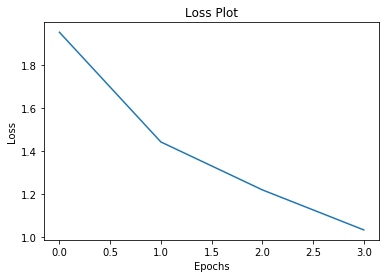

In [94]:
plt.plot(loss_plot)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Plot')
plt.show()

## Caption!

* evaluate 함수는 training loop 과 비슷하지만 teacher forcing 을 하지 않고 각 time step 별 decoder input 은 이전 step 의 prediction 이 된다. 
* end token 이 나오면 prediction 을 중지  
* 매 time step 별로 attention weight 를 저장

In [95]:
def plot_attention(image, result, attention_plot):
    temp_image = np.array(Image.open(image))

    fig = plt.figure(figsize=(5, 5))
    plt.imshow(temp_image)

    fig = plt.figure(figsize=(10, 10))
    len_result = len(result)
    for l in range(len_result):
        temp_att = np.resize(attention_plot[l], (8, 8))
        ax = fig.add_subplot(len_result//2, len_result//2, l+1)
        ax.set_title(result[l])
        img = ax.imshow(temp_image)
        ax.imshow(temp_att, cmap='gray', alpha=0.6, extent=img.get_extent())

    plt.tight_layout()
    plt.show()

(1, 299, 299, 3)
(1, 8, 8, 2048)
(1, 64, 2048)
Real Caption: <start> the black and brown dog is running through the snow <end>
Prediction Caption: dog is jumping up one running on the snow <end>


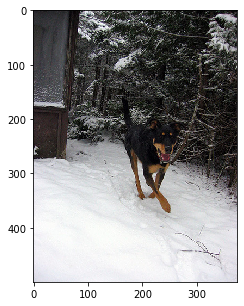

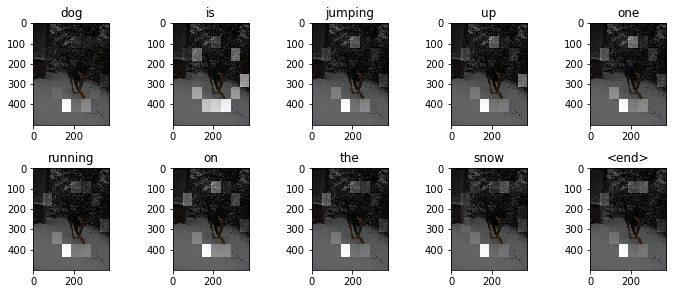

In [101]:
# captions on the validation set
from PIL import Image

rid = np.random.randint(0, len(img_name_val))
image = img_name_val[rid]
real_caption = ' '.join([tokenizer.index_word[i] for i in cap_val[rid] if i not in [0]])
result, attention_plot = evaluate(image)

print ('Real Caption:', real_caption)
print ('Prediction Caption:', ' '.join(result))
plot_attention(image, result, attention_plot)

## Try it on your own images

(1, 299, 299, 3)
(1, 8, 8, 2048)
(1, 64, 2048)
Prediction Caption: the white surfers crashing water <end>


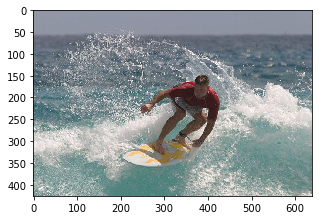

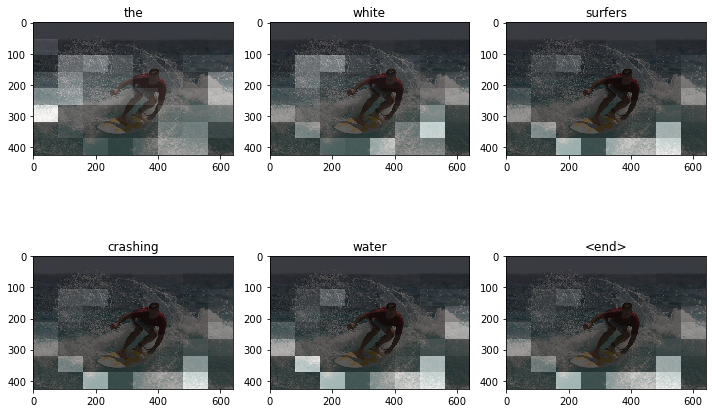

In [107]:
image_url = 'https://tensorflow.org/images/surf.jpg'
image_extension = image_url[-4:]
image_path = tf.keras.utils.get_file('image'+image_extension,
                                     origin=image_url)

result, attention_plot = evaluate(image_path)
print ('Prediction Caption:', ' '.join(result))
plot_attention(image_path, result, attention_plot)